# 04 - Exploratory Data Analysis & Visualization

**Mục tiêu:** Khám phá dữ liệu nhiệt độ bề mặt Trái Đất, phát hiện các xu hướng, mẫu mùa vụ, và mối liên hệ giữa các biến để xây dựng nền tảng cho Feature Engineering.

**Quy trình:** Notebook 03 (Data Cleaning) → **Notebook 04 (EDA & Visualization)** → Notebook 05 (Feature Engineering)

## 1. Giới Thiệu

### 1.1. Mục tiêu của EDA

Exploratory Data Analysis (EDA) giúp:
1. **Hiểu sâu dữ liệu:** Phân bố, xu hướng, mối quan hệ giữa các biến.
2. **Phát hiện các yếu tố ảnh hưởng:** Xác định các cột có tác động mạnh đến biến mục tiêu hoặc các xu hướng chính.
3. **Chuẩn bị cho Feature Engineering:** Những phát hiện này sẽ được sử dụng để tạo các đặc trưng mới.
4. **Nhận diện vấn đề tiềm ẩn:** Outliers, missing values không được xử lý, hoặc các bất thường cần lưu ý.

### 1.2. 4 Câu hỏi cốt lõi mà Notebook 04 trả lời

1. **Dữ liệu có đặc điểm gì?** (phân bố, xu hướng, mối quan hệ)
2. **Những yếu tố nào ảnh hưởng đến nhiệt độ?** (thông qua trực quan hóa và phân tích)
3. **Kết quả có ý nghĩa gì đối với bài toán dự báo?** (không chỉ mô tả biểu đồ mà còn giải thích ý nghĩa)
4. **Những phát hiện này sẽ được sử dụng như thế nào ở bước tiếp theo?** (nền tảng cho Feature Engineering)

## 2. Đọc Dữ Liệu

### 2.1. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("Thư viện đã được import")

Thư viện đã được import


### 2.2. Xác định đường dẫn dữ liệu

In [2]:
# Tìm project root dựa trên thư mục 'data' và 'notebooks'
def find_project_root():
    current = Path.cwd()
    while current != current.parent:
        # Tìm folder chứa cả 'data' và 'notebooks' hoặc 'notebooks_v1'
        if (current / 'data').exists() and ((current / 'notebooks').exists() or (current / 'notebooks_v1').exists()):
            return current
        current = current.parent
    return Path.cwd()

PROJECT_ROOT = find_project_root()
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
REPORT_IMAGES = PROJECT_ROOT / 'reports' / 'images'

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Processed: {DATA_PROCESSED}")
print(f"Report Images: {REPORT_IMAGES}")

Project Root: e:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis
Data Processed: e:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\data\processed
Report Images: e:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\reports\images


### 2.3. Đọc dữ liệu sạch từ PostgreSQL

Notebook 04 chỉ sử dụng bảng `public.cleaned_city_temperature` đã được Notebook 03 làm sạch và lưu vào PostgreSQL. Cách này bảo đảm EDA luôn làm việc với một nguồn dữ liệu tập trung, nhất quán với pipeline.

In [3]:
import os
import psycopg2
from dotenv import load_dotenv

# Đọc thông tin kết nối từ file .env ở thư mục gốc dự án.
load_dotenv(PROJECT_ROOT / '.env')

DB_CONFIG = {
    'host': os.getenv('DB_HOST'),
    'port': os.getenv('DB_PORT', '5432'),
    'dbname': os.getenv('DB_NAME'),
    'user': os.getenv('DB_USER'),
    'password': os.getenv('DB_PASSWORD'),
}

missing_config = [key for key, value in DB_CONFIG.items() if not value]
if missing_config:
    raise ValueError('Thiếu cấu hình trong .env: ' + ', '.join(missing_config))

# Đọc bảng sạch được tạo sau Notebook 03.
with psycopg2.connect(**DB_CONFIG) as connection:
    df = pd.read_sql_query(
        'SELECT * FROM public.cleaned_city_temperature;',
        connection,
    )

# Chuẩn hóa ngày để các phân tích theo thời gian hoạt động nhất quán.
df['observation_date'] = pd.to_datetime(df['observation_date'], errors='raise')

print(f'Kích thước: {df.shape[0]:,} dòng - {df.shape[1]} cột')

Kích thước: 5,579,085 dòng - 32 cột


### 2.4. Kiểm tra dữ liệu cơ bản

#### 2.4.1. Bảng thông tin cột

Cell này lập một bảng tóm tắt cho toàn bộ cột: kiểu dữ liệu, số giá trị thiếu và tỷ lệ thiếu. Cách tạo bảng bằng pandas giúp thay thế vòng lặp in từng cột, nên kết quả gọn và dễ so sánh hơn.

In [4]:
column_profile = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'missing_values': df.isnull().sum().values
})

display(column_profile)

,column,dtype,missing_values
0,observation_date,datetime64[s],0
1,year,int64,0
2,month,int64,0
3,quarter,int64,0
4,decade,int64,0
5,city_name,str,0
6,country_name,str,0
7,latitude,float64,0
8,longitude,float64,0
9,is_major_city,bool,0


#### 2.4.2. Mẫu dữ liệu

Hiển thị năm dòng đầu để kiểm tra nhanh tên cột, dạng giá trị và việc chuyển `observation_date` sang kiểu ngày tháng trước khi phân tích.

In [5]:
display(df.head())

,observation_date,year,month,quarter,decade,city_name,country_name,latitude,longitude,is_major_city,city_average_temperature,city_average_temperature_uncertainty,country_matched,country_average_temperature,country_average_temperature_uncertainty,global_matched,land_average_temperature,land_average_temperature_uncertainty,land_max_temperature,land_max_temperature_uncertainty,land_min_temperature,land_min_temperature_uncertainty,land_and_ocean_average_temperature,land_and_ocean_average_temperature_uncertainty,major_city_matched,major_city_average_temperature,major_city_average_temperature_uncertainty,city_uncertainty_available,country_temperature_available,global_temperature_available,major_city_temperature_available,city_temperature_iqr_outlier
0,1863-01-01,1863,1,1,1860,A Coruña,Spain,42.59,-8.73,False,8.131,2.430,True,5.923,2.171,True,3.034,1.228,8.462,3.188,-1.766,2.51,13.296,0.417,False,NaN,NaN,True,True,True,False,False
1,1863-01-01,1863,1,1,1860,Aachen,Germany,50.63,6.34,False,2.992,2.230,True,2.049,2.282,True,3.034,1.228,8.462,3.188,-1.766,2.51,13.296,0.417,False,NaN,NaN,True,True,True,False,False
2,1863-01-01,1863,1,1,1860,Abadan,Iran,29.74,48.00,False,10.934,1.847,True,4.057,1.889,True,3.034,1.228,8.462,3.188,-1.766,2.51,13.296,0.417,False,NaN,NaN,True,True,True,False,False
3,1863-01-01,1863,1,1,1860,Abakan,Russia,53.84,91.36,False,-17.532,2.227,True,-24.312,1.862,True,3.034,1.228,8.462,3.188,-1.766,2.51,13.296,0.417,False,NaN,NaN,True,True,True,False,True
4,1863-01-01,1863,1,1,1860,Abbotsford,Canada,49.03,-122.45,False,-0.377,3.315,True,-22.554,2.829,True,3.034,1.228,8.462,3.188,-1.766,2.51,13.296,0.417,False,NaN,NaN,True,True,True,False,False


#### 2.4.3. Thống kê mô tả các biến số

Chỉ các cột số được đưa vào `describe()`. Bảng được chuyển vị để mỗi dòng là một biến, giúp so sánh count, mean, độ lệch chuẩn, min và các phân vị dễ hơn.

In [6]:
numeric_summary = df.describe().T
display(numeric_summary)

,count,mean,min,25%,50%,75%,max,std
observation_date,5579085,1939-01-15 23:09:53,1863-01-01 00:00:00,1901-11-01 00:00:00,1939-02-01 00:00:00,1976-05-01 00:00:00,2013-09-01 00:00:00,NaN
year,5579085.0,1938.584267,1863.0,1901.0,1939.0,1976.0,2013.0,43.130904
month,5579085.0,6.491461,1.0,3.0,6.0,9.0,12.0,3.450317
quarter,5579085.0,2.497298,1.0,1.0,2.0,3.0,4.0,1.117522
decade,5579085.0,1934.093178,1860.0,1900.0,1930.0,1970.0,2010.0,43.28725
latitude,5579085.0,23.469818,-52.24,10.45,28.13,39.38,69.92,23.131934
longitude,5579085.0,34.966851,-151.13,-7.54,43.64,106.22,159.55,76.763146
city_average_temperature,5579085.0,17.50208,-42.704,11.606,19.826,25.637,39.156,10.193546
city_average_temperature_uncertainty,5579085.0,0.583612,0.034,0.293,0.436,0.72,12.694,0.446119
country_average_temperature,5572950.0,15.671397,-30.497,8.493,18.855,25.101,33.148,11.480214


#### 2.4.4. Kết luận sau kiểm tra

## 3. Khám Phá Dữ Liệu (Exploratory Data Analysis)

### 3.1 Correlation Analysis (Phân tích tương quan)

#### 3.1.1. Ma trận tương quan

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

pd.set_option('display.float_format', '{:.4f}'.format)
print(f"Ma trận tương quan giữa các biến số:")
print(corr_matrix)

Ma trận tương quan giữa các biến số:
                                                  year   month  quarter  \
year                                            1.0000 -0.0045  -0.0044   
month                                          -0.0045  1.0000   0.9716   
quarter                                        -0.0044  0.9716   1.0000   
decade                                          0.9978 -0.0046  -0.0044   
latitude                                       -0.0116  0.0002   0.0001   
longitude                                       0.0002  0.0000   0.0000   
city_average_temperature                        0.0479  0.1037   0.1067   
city_average_temperature_uncertainty           -0.6002 -0.0575  -0.0596   
country_average_temperature                     0.0460  0.0968   0.0996   
country_average_temperature_uncertainty        -0.7133 -0.0450  -0.0463   
land_average_temperature                        0.0888  0.2679   0.2782   
land_average_temperature_uncertainty           -0.8495 -0.0882 

✓ Đã lưu: reports/images/01_correlation_heatmap.png


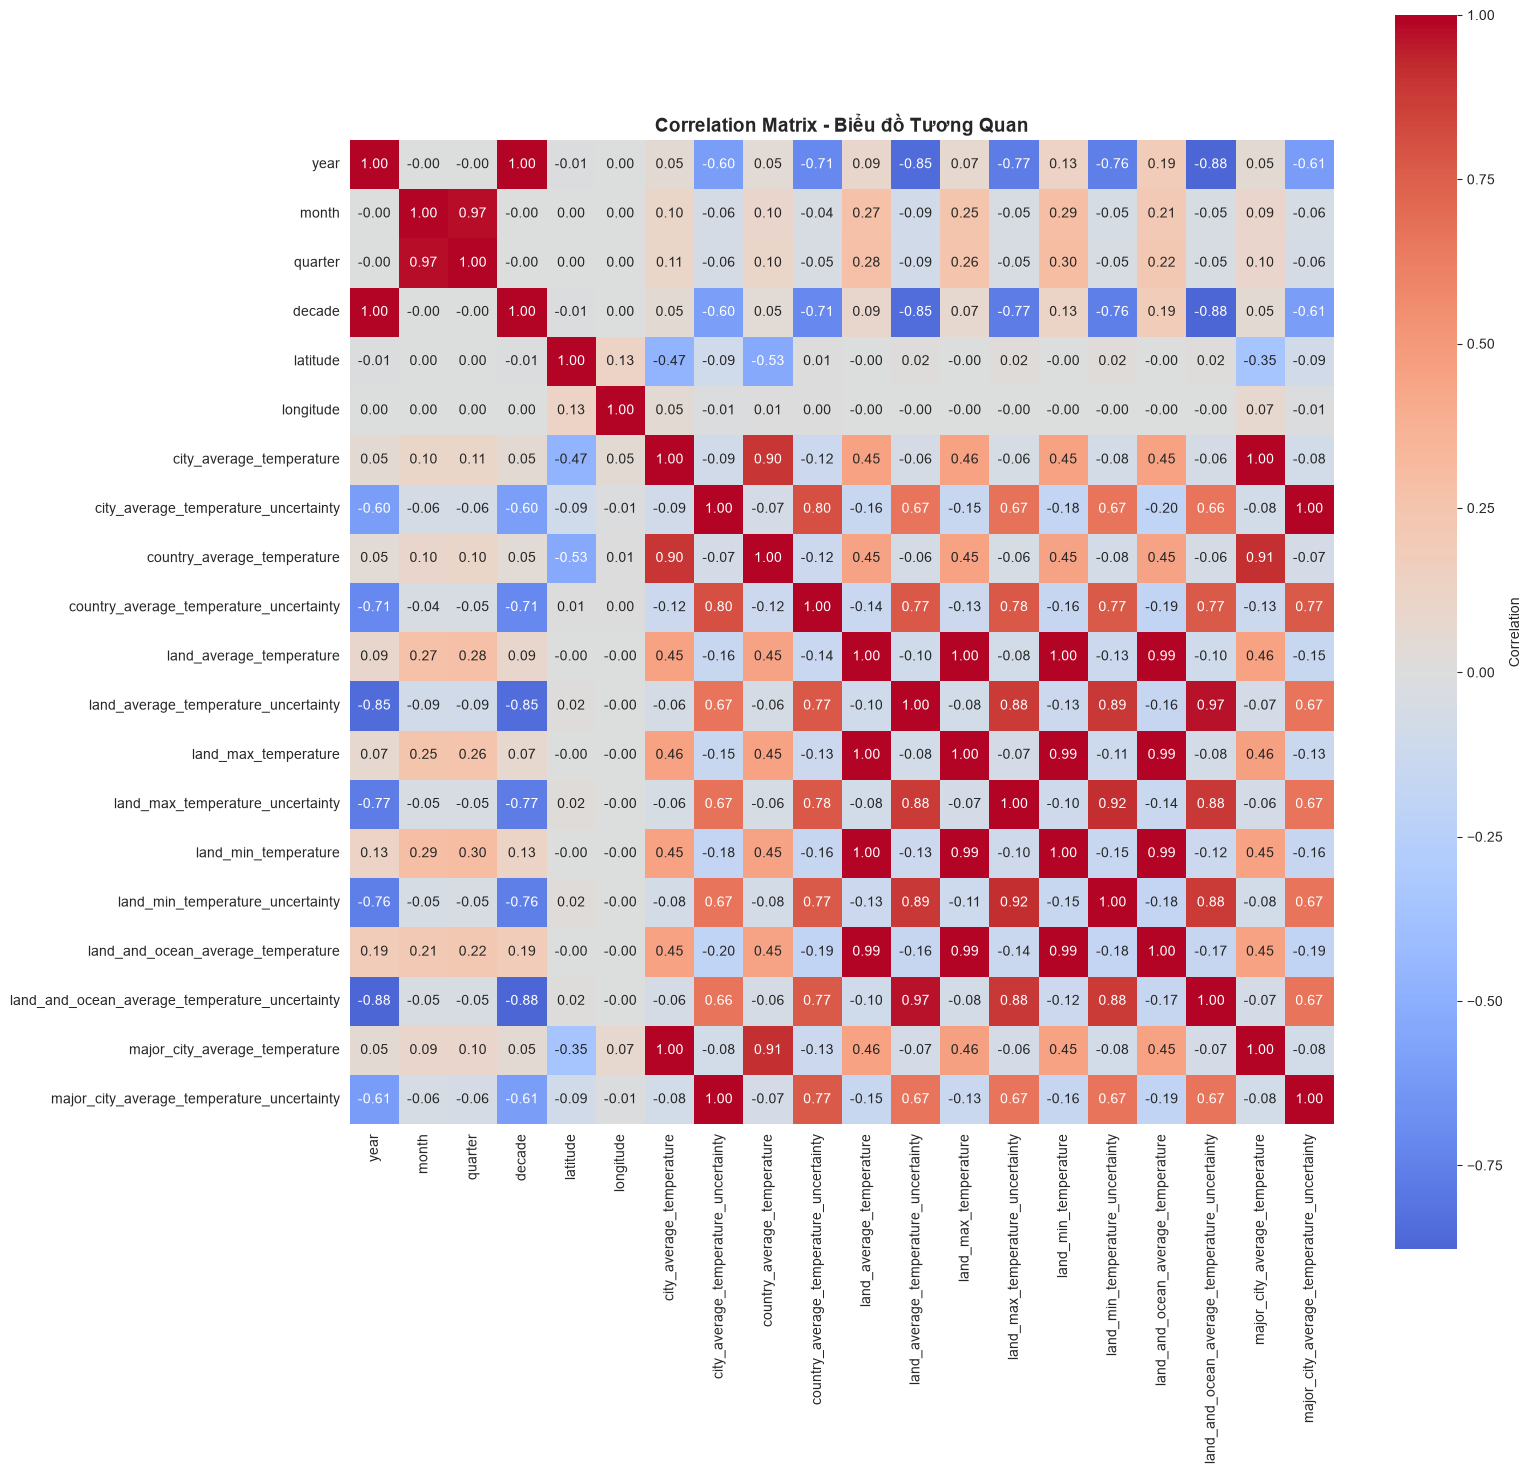

In [8]:
n_vars = len(corr_matrix)
fig_size = max(8, min(16, n_vars * 0.8 + 2))
plt.figure(figsize=(fig_size, fig_size * 0.95))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix - Biểu đồ Tương Quan', fontsize=14, fontweight='bold')
plt.tight_layout()

    # Lưu ảnh
if REPORT_IMAGES.exists():
    plt.savefig(REPORT_IMAGES / '01_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    print("✓ Đã lưu: reports/images/01_correlation_heatmap.png")

plt.show()

#### 3.1.2 Nhận xét tương quan

**Quan sát chính:**
- Các biến nhiệt độ thường có tương quan cao với nhau (ví dụ: land_average_temperature và land_max_temperature).
- Uncertainty (độ không chắc chắn) có thể không tương quan mạnh với các giá trị nhiệt độ nếu chất lượng đo lường không phụ thuộc vào mức độ nhiệt độ.
- **Ý nghĩa cho Feature Engineering:** Nếu tương quan rất cao (> 0.95), có thể xảy ra multicollinearity, cần cân nhắc loại bỏ một trong các biến.

### 3.2 Target Analysis (Phân tích biến mục tiêu)

#### 3.2.1 Xác định biến mục tiêu

Đối với dự án này, biến mục tiêu duy nhất là:

- `city_average_temperature`: nhiệt độ trung bình của thành phố.

Biến này là giá trị cần được phân tích trong Notebook 04 và dự báo ở các notebook Machine Learning phía sau.

In [9]:
# Bước 1: Xác định biến mục tiêu duy nhất và loại các giá trị thiếu.
target_col = 'city_average_temperature'

if target_col not in df.columns:
    raise KeyError(f'Không tìm thấy cột mục tiêu: {target_col}')

target_data = df[target_col].dropna()
if target_data.empty:
    raise ValueError(f'Cột {target_col} không có giá trị hợp lệ.')

print(f'Biến mục tiêu duy nhất: {target_col}')
print(f'Số quan sát hợp lệ: {len(target_data):,}')

Biến mục tiêu duy nhất: city_average_temperature
Số quan sát hợp lệ: 5,579,085


#### 3.2.2. Thống kê mô tả biến mục tiêu

Bảng này tóm tắt mức nhiệt độ điển hình và mức độ phân tán của biến mục tiêu. Các chỉ số được tính trên những dòng có nhiệt độ City hợp lệ.

In [10]:
target_summary = pd.DataFrame({
    'metric': ['count', 'mean', 'median', 'std', 'min', 'max', 'range'],
    'value': [
        len(target_data),
        target_data.mean(),
        target_data.median(),
        target_data.std(),
        target_data.min(),
        target_data.max(),
        target_data.max() - target_data.min(),
    ],
})

display(target_summary)

,metric,value
0,count,5579085.0000
1,mean,17.5021
2,median,19.8260
3,std,10.1935
4,min,-42.7040
5,max,39.1560
6,range,81.8600


#### 3.2.3. Histogram nhiệt độ City

Histogram cho thấy hình dạng phân bố của biến mục tiêu. Đường dọc thể hiện mean và median để hỗ trợ nhận biết độ lệch của phân bố.

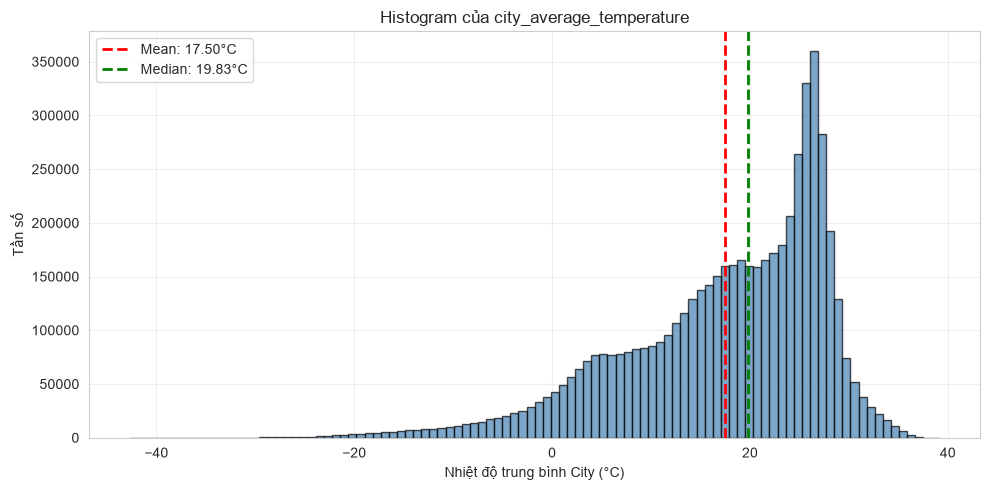

In [11]:
n_bins = max(20, min(100, len(target_data) // 100 + 30))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(target_data, bins=n_bins, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(target_data.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {target_data.mean():.2f}°C')
ax.axvline(target_data.median(), color='green', linestyle='--', linewidth=2,
           label=f'Median: {target_data.median():.2f}°C')
ax.set_xlabel('Nhiệt độ trung bình City (°C)')
ax.set_ylabel('Tần số')
ax.set_title(f'Histogram của {target_col}')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(REPORT_IMAGES / '02_target_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

#### 3.2.4. Boxplot nhiệt độ City

Boxplot hiển thị median, các phân vị và những quan sát nằm xa phần lớn phân bố. Các điểm cực trị không được tự động xem là lỗi vì Notebook 03 đã kiểm tra outlier khí hậu và gắn cờ riêng.

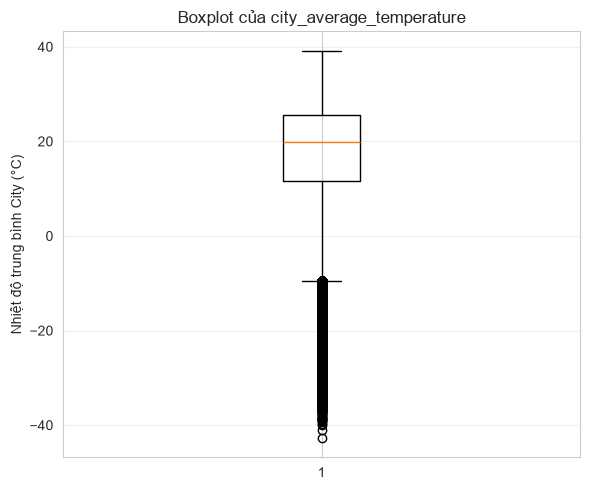

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(target_data, vert=True)
ax.set_ylabel('Nhiệt độ trung bình City (°C)')
ax.set_title(f'Boxplot của {target_col}')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(REPORT_IMAGES / '03_target_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

#### 3.2.5. Nhận xét về phân bố biến mục tiêu

Biến mục tiêu `city_average_temperature` có **5.579.085** quan sát hợp lệ. Nhiệt độ trung bình là **17,50°C**, thấp hơn median **19,83°C**; độ lệch chuẩn là **10,19°C**. Khoảng giá trị rất rộng, từ **−42,70°C** đến **39,16°C** (biên độ **81,86°C**), phản ánh khác biệt khí hậu lớn giữa thành phố, vĩ độ và mùa.

Histogram cho thấy phần lớn quan sát tập trung ở vùng nhiệt độ ấm khoảng 15–30°C, nhưng có đuôi kéo dài rõ về phía nhiệt độ âm. Vì mean thấp hơn median, phân bố **lệch trái**; các tháng mùa đông tại những thành phố vĩ độ cao kéo trung bình chung xuống.

Boxplot thể hiện nhiều điểm nằm dưới whisker thấp. Đây là các cực trị lạnh theo tiêu chí thống kê, không phải tự động là dữ liệu sai: Notebook 03 đã kiểm tra chúng theo mùa, thành phố và tọa độ, sau đó giữ lại cùng cờ `city_temperature_iqr_outlier`. Do nhiệt độ có thể âm và sự lệch trái mang ý nghĩa khí hậu, không áp dụng log/sqrt transform cho target chỉ dựa trên hình dạng phân bố.


**Quan sát:**
- **Hình dạng phân bố:** Bình thường, lệch trái/phải, hoặc nhiều peak?
- **Outliers:** Có nhiệt độ bất thường (quá cao/quá thấp) không?
- **Ý nghĩa:** Phân bố cân bằng là tốt cho mô hình hồi quy. Nếu lệch, có thể cần transform (log, sqrt).
- **Ứng dụng cho ML:** Nếu phân bố bình thường, các mô hình tuyến tính sẽ hiệu quả hơn.

### 3.3 Univariate Analysis (Phân tích từng biến riêng lẻ)

#### 3.3.1 Tổng quan biến quốc gia và thành phố

Phần này phân tích riêng các biến phân loại và địa lý cốt lõi của bộ dữ liệu City. Dữ liệu đã được nạp vào `df` ở Mục 2.3, vì vậy các cell dưới đây chỉ sử dụng lại DataFrame đó; không đọc lại CSV, không kết nối lại PostgreSQL và không dùng vòng lặp tạo biểu đồ tự động.

Các phân tích tập trung vào độ đa dạng quốc gia/thành phố, mức độ bao phủ bản ghi, nhiệt độ trung bình theo quốc gia và các địa điểm có nhiệt độ trung bình cực trị. Phân tích theo thời gian được trình bày riêng ở Mục 3.6 để tránh lặp nội dung.


In [13]:
# Thống kê số giá trị khác nhau và tỷ lệ thiếu của hai biến danh mục chính.
CATEGORICAL_COLUMNS = ['country_name', 'city_name']

categorical_profile = pd.DataFrame({
    'column': CATEGORICAL_COLUMNS,
    'unique_values': [df[column].nunique() for column in CATEGORICAL_COLUMNS],
    'missing_count': [df[column].isna().sum() for column in CATEGORICAL_COLUMNS],
})
categorical_profile['missing_percent'] = (
    categorical_profile['missing_count'] / len(df) * 100
).round(4)

display(categorical_profile)


,column,unique_values,missing_count,missing_percent
0,country_name,50,0,0.0000
1,city_name,3070,0,0.0000


##### Nhận xét kết quả

Kết quả cho thấy dữ liệu sau làm sạch bao phủ đúng **50 quốc gia** và **3.070 thành phố**. Cả hai biến `country_name` và `city_name` đều không có giá trị thiếu, nên có thể dùng trực tiếp để tổng hợp, trực quan hóa hoặc mã hóa đặc trưng ở các bước sau. Tuy nhiên, số lượng thành phố lớn hơn nhiều số quốc gia; khi xây dựng mô hình cần cân nhắc cách mã hóa biến thành phố để tránh tạo quá nhiều biến giả.


#### 3.3.2 Phân bố số bản ghi theo quốc gia

Bảng và biểu đồ dưới đây hiển thị 15 quốc gia có nhiều bản ghi City nhất. Chỉ số này phản ánh mức độ bao phủ của dữ liệu sau pipeline, không phải mức độ nóng/lạnh của quốc gia. Việc hiển thị top 15 giúp biểu đồ dễ đọc trong khi bảng `country_counts` vẫn giữ kết quả cho toàn bộ quốc gia.


,country_name,record_count,record_percent
0,India,693711,12.4300
1,China,686966,12.3100
2,United States,464897,8.3300
3,Brazil,392342,7.0300
4,Japan,316032,5.6600
5,Russia,282047,5.0600
6,Indonesia,256588,4.6000
7,Mexico,175473,3.1500
8,Nigeria,151971,2.7200
9,Germany,146448,2.6200


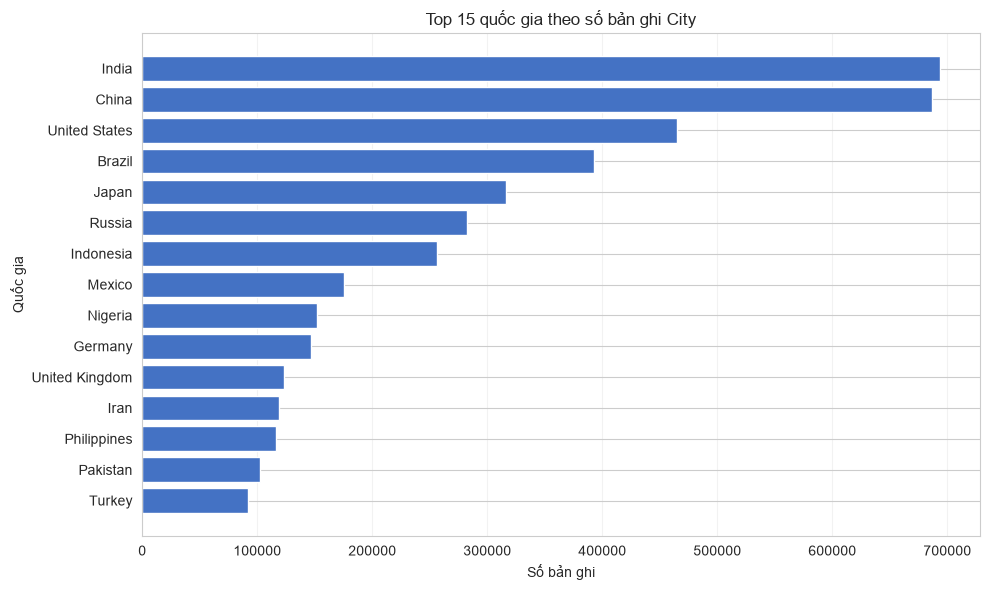

In [14]:
# Đếm số bản ghi của từng quốc gia và chọn 15 quốc gia có độ bao phủ lớn nhất.
country_counts = (
    df['country_name']
    .value_counts()
    .rename_axis('country_name')
    .reset_index(name='record_count')
)
country_counts['record_percent'] = (
    country_counts['record_count'] / len(df) * 100
).round(2)

top_countries = country_counts.head(15).sort_values('record_count')
display(top_countries.sort_values('record_count', ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_countries['country_name'], top_countries['record_count'], color='#4472C4')
ax.set_title('Top 15 quốc gia theo số bản ghi City')
ax.set_xlabel('Số bản ghi')
ax.set_ylabel('Quốc gia')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.savefig(REPORT_IMAGES / '04_country_record_counts.png', dpi=300, bbox_inches='tight')
plt.show()


##### Nhận xét kết quả

Biểu đồ cho thấy số bản ghi phân bố không đồng đều giữa các quốc gia. India (**693.711** dòng, **12,43%**) và China (**686.966** dòng, **12,31%**) có độ bao phủ lớn nhất; riêng hai quốc gia này chiếm **24,74%** toàn bộ dữ liệu. Năm quốc gia đứng đầu chiếm khoảng **45,76%**, vì vậy các phân tích hoặc mô hình tổng hợp có thể chịu ảnh hưởng lớn hơn từ những quốc gia có nhiều thành phố/bản ghi.

Đây là đặc điểm về mức độ bao phủ của dữ liệu City sau khi chọn 50 quốc gia, không chứng minh rằng các quốc gia này có nhiệt độ cao hơn hoặc thấp hơn. Khi đánh giá mô hình theo từng quốc gia, nên báo cáo thêm chỉ số theo nhóm để tránh việc kết quả chung bị chi phối bởi các quốc gia có nhiều dòng.


#### 3.3.3 Nhiệt độ trung bình theo quốc gia

Mục này tổng hợp trực tiếp `city_average_temperature` theo `country_name`, khác với Mục 3.3.2 chỉ đếm số bản ghi. Hai biểu đồ hiển thị 10 quốc gia có nhiệt độ City trung bình thấp nhất và cao nhất để mô tả khác biệt khí hậu trong tập dữ liệu nghiên cứu.

Giá trị là trung bình theo các bản ghi City của từng quốc gia, không phải trung bình theo diện tích hoặc dân số. Vì độ bao phủ dữ liệu khác nhau giữa các quốc gia, kết quả dùng để diễn giải xu hướng khí hậu trong dữ liệu, không phải xếp hạng khí hậu tuyệt đối.


In [15]:
# Tổng hợp target theo quốc gia và lưu số bản ghi để diễn giải độ bao phủ.
country_temperature = (
    df.groupby('country_name', as_index=False)
    .agg(
        mean_city_temperature=(target_col, 'mean'),
        record_count=(target_col, 'size'),
        city_count=('city_name', 'nunique'),
    )
    .sort_values('mean_city_temperature')
)

coldest_countries = country_temperature.head(10).copy()
hottest_countries = country_temperature.tail(10).copy()

COUNTRY_TEMPERATURE_EXTREMES = pd.concat([
    coldest_countries.assign(group='Coldest 10 countries'),
    hottest_countries.assign(group='Hottest 10 countries'),
])

display(COUNTRY_TEMPERATURE_EXTREMES)
print('Lạnh nhất:', coldest_countries.iloc[0]['country_name'])
print('Nóng nhất:', hottest_countries.iloc[-1]['country_name'])


,country_name,mean_city_temperature,record_count,city_count,group
37,Russia,3.3193,282047,156,Coldest 10 countries
24,Kazakhstan,4.5114,27120,15,Coldest 10 countries
8,Canada,5.1059,45225,25,Coldest 10 countries
3,Belarus,6.3176,14464,8,Coldest 10 countries
35,Poland,7.8352,68704,38,Coldest 10 countries
45,Ukraine,8.0019,43392,24,Coldest 10 countries
17,Germany,8.6491,146448,81,Coldest 10 countries
36,Romania,9.0391,45200,25,Coldest 10 countries
46,United Kingdom,9.2581,122944,68,Coldest 10 countries
30,Netherlands,9.2676,43392,24,Coldest 10 countries


Lạnh nhất: Russia
Nóng nhất: Sri Lanka


Hai biểu đồ dùng cùng đơn vị °C nhưng tách thành hai panel để nhãn quốc gia dễ đọc. Bảng phía trên cung cấp số bản ghi và số thành phố, giúp tránh diễn giải thứ hạng nhiệt độ mà bỏ qua độ bao phủ dữ liệu.


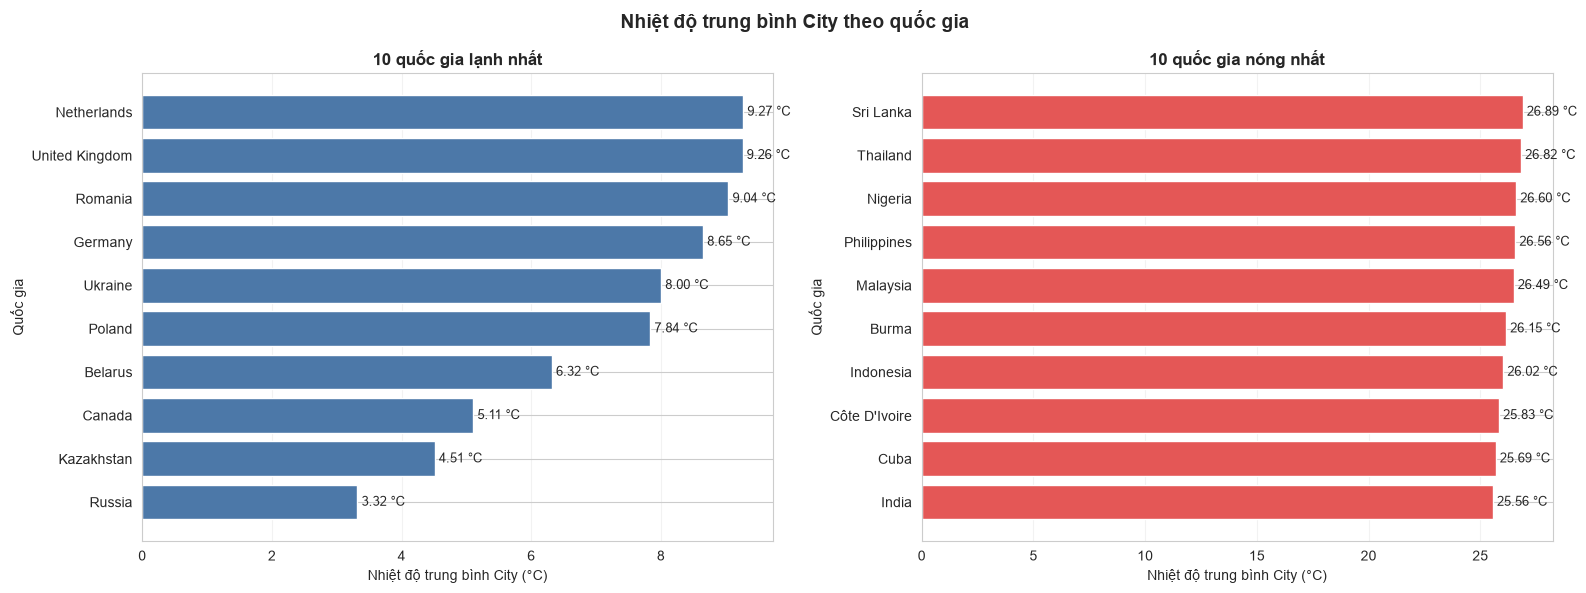

In [16]:
# Vẽ riêng 10 quốc gia lạnh nhất và nóng nhất theo nhiệt độ City trung bình.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_specs = [
    (coldest_countries, '10 quốc gia lạnh nhất', '#4C78A8'),
    (hottest_countries, '10 quốc gia nóng nhất', '#E45756'),
]

for ax, (plot_df, title, color) in zip(axes, plot_specs):
    plot_df = plot_df.sort_values('mean_city_temperature')
    bars = ax.barh(
        plot_df['country_name'],
        plot_df['mean_city_temperature'],
        color=color,
    )
    ax.bar_label(bars, fmt='%.2f °C', padding=3, fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Nhiệt độ trung bình City (°C)')
    ax.set_ylabel('Quốc gia')
    ax.grid(axis='x', alpha=0.25)

fig.suptitle('Nhiệt độ trung bình City theo quốc gia', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORT_IMAGES / '06_country_temperature_extremes.png', dpi=300, bbox_inches='tight')
plt.show()


##### Nhận xét kết quả

Hai biểu đồ cho thấy nhiệt độ City trung bình khác biệt rõ giữa các quốc gia trong tập dữ liệu. Nhóm quốc gia lạnh nhất thường thuộc vùng vĩ độ cao hoặc có khí hậu lục địa; nhóm nóng nhất thường thuộc vùng nhiệt đới và cận nhiệt đới. Kết quả này củng cố vai trò của feature địa lý và mùa vụ trong các bước sau.

Thứ hạng không được diễn giải là nhiệt độ trung bình tuyệt đối của toàn bộ quốc gia ngoài thực tế. Mỗi giá trị là trung bình của các bản ghi City có trong dữ liệu, trong khi số thành phố và số quan sát giữa các quốc gia không đồng đều. Vì vậy, cần đọc biểu đồ cùng `record_count` và Mục 3.3.2 về độ bao phủ dữ liệu.


#### 3.3.4 Địa điểm có nhiệt độ trung bình cao và thấp

Nhiệt độ trung bình được tổng hợp theo tổ hợp `country_name`, `city_name`, `latitude` và `longitude`. Cách nhóm này tránh gộp nhầm các thành phố trùng tên ở những quốc gia khác nhau. Bảng và biểu đồ đối chiếu 10 địa điểm có nhiệt độ trung bình thấp nhất với 10 địa điểm cao nhất; đây là bước thăm dò để diễn giải theo vị trí địa lý, không phải quy tắc để xóa dữ liệu.


,location,latitude,longitude,mean_city_temperature,group
0,"Norilsk, Russia",69.9200,88.8300,-11.7193,Coldest 10
1,"Kyzyl, Russia",52.2400,94.6000,-6.0503,Coldest 10
2,"Chita, Russia",52.2400,112.9900,-4.1770,Coldest 10
3,"Ust Ilimsk, Russia",58.6600,101.5400,-3.8240,Coldest 10
4,"Nefteyugansk, Russia",61.8800,73.0200,-3.3340,Coldest 10
5,"Surgut, Russia",61.8800,73.0200,-3.3340,Coldest 10
6,"Ulan Ude, Russia",52.2400,107.7400,-3.0019,Coldest 10
7,"Bratsk, Russia",55.4500,102.0500,-2.6434,Coldest 10
8,"Hailar, China",49.0300,120.0000,-2.3348,Coldest 10
9,"Yakeshi, China",49.0300,120.0000,-2.3348,Coldest 10


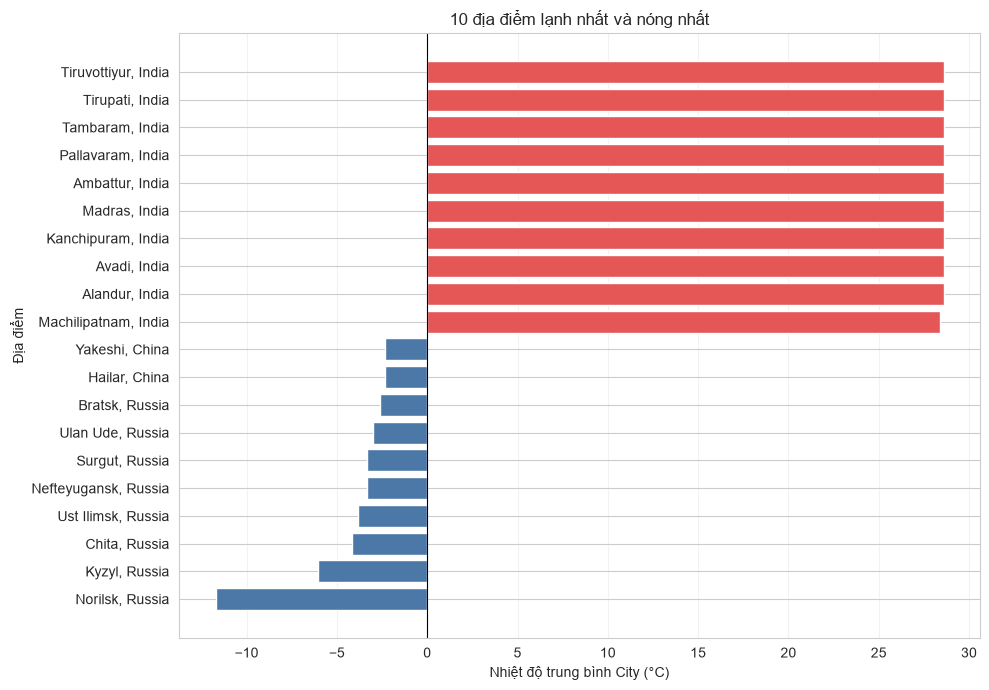

In [17]:
# Tính nhiệt độ trung bình theo từng địa điểm duy nhất và chọn hai nhóm cực trị.
LOCATION_COLUMNS = ['country_name', 'city_name', 'latitude', 'longitude']

location_temperature = (
    df.groupby(LOCATION_COLUMNS, as_index=False)[target_col]
    .mean()
    .rename(columns={target_col: 'mean_city_temperature'})
)

coldest_locations = location_temperature.nsmallest(10, 'mean_city_temperature').copy()
coldest_locations['group'] = 'Coldest 10'
hottest_locations = location_temperature.nlargest(10, 'mean_city_temperature').copy()
hottest_locations['group'] = 'Hottest 10'

temperature_extremes = pd.concat(
    [coldest_locations, hottest_locations],
    ignore_index=True,
).sort_values('mean_city_temperature')
temperature_extremes['location'] = (
    temperature_extremes['city_name'] + ', ' + temperature_extremes['country_name']
)

display(
    temperature_extremes[
        ['location', 'latitude', 'longitude', 'mean_city_temperature', 'group']
    ]
)

colors = temperature_extremes['group'].map({
    'Coldest 10': '#4C78A8',
    'Hottest 10': '#E45756',
})
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    temperature_extremes['location'],
    temperature_extremes['mean_city_temperature'],
    color=colors,
)
ax.set_title('10 địa điểm lạnh nhất và nóng nhất')
ax.set_xlabel('Nhiệt độ trung bình City (°C)')
ax.set_ylabel('Địa điểm')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.savefig(REPORT_IMAGES / '05_location_temperature_extremes.png', dpi=300, bbox_inches='tight')
plt.show()


##### Nhận xét kết quả

Nhóm lạnh nhất tập trung tại Nga và Trung Quốc ở vĩ độ cao hoặc nội lục lạnh; Norilsk, Russia có nhiệt độ trung bình thấp nhất (**−11,72°C**) và nằm ở vĩ độ **69,92°B**. Ngược lại, các địa điểm nóng nhất trong kết quả đều ở India, với nhiệt độ trung bình khoảng **28,40–28,59°C** tại vĩ độ thấp hơn. Mẫu hình này phù hợp với khác biệt khí hậu theo vị trí địa lý, vì vậy các giá trị cực trị này không nên bị coi là lỗi chỉ dựa trên độ lớn của nhiệt độ.

Một số thành phố trong bảng có cùng tọa độ và cùng nhiệt độ trung bình. Đây có thể là do dữ liệu nguồn dùng cùng tọa độ đại diện cho các thành phố lân cận, nên `latitude` và `longitude` vẫn cần được diễn giải cùng với tên thành phố và quốc gia, thay vì dùng riêng lẻ để nhận diện một thành phố duy nhất.


### 3.4 Correlation with Target Variable (Tương quan với biến mục tiêu)


📊 Tương quan của các biến với city_average_temperature:
major_city_average_temperature                    1.0000
city_average_temperature                          1.0000
country_average_temperature                       0.8972
land_max_temperature                              0.4554
land_average_temperature                          0.4549
land_min_temperature                              0.4520
land_and_ocean_average_temperature                0.4515
quarter                                           0.1067
month                                             0.1037
longitude                                         0.0484
year                                              0.0479
decade                                            0.0477
land_max_temperature_uncertainty                 -0.0559
land_and_ocean_average_temperature_uncertainty   -0.0606
land_average_temperature_uncertainty             -0.0610
land_min_temperature_uncertainty                 -0.0769
major_city_average_temperature_

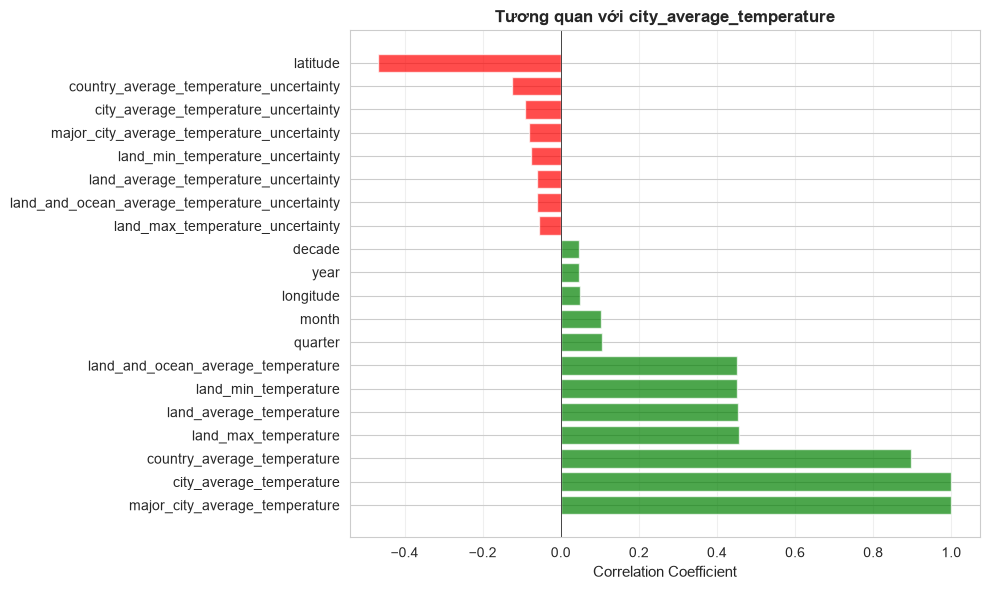

In [18]:
if df is not None and target_col:
    # Tính tương quan của các biến số với target
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    if numeric_cols:
        correlations = df[numeric_cols].corr()[target_col].sort_values(ascending=False)
        
        print(f"\n📊 Tương quan của các biến với {target_col}:")
        print(correlations)
        
        # Tính kích thước phù hợp
        n_vars = len(correlations)
        fig_height = max(5, n_vars * 0.3)
        
        # Biểu đồ thanh
        fig, ax = plt.subplots(figsize=(10, fig_height))
        colors = ['green' if x > 0 else 'red' for x in correlations.values]
        ax.barh(range(len(correlations)), correlations.values, color=colors, alpha=0.7)
        ax.set_yticks(range(len(correlations)))
        ax.set_yticklabels(correlations.index, fontsize=10)
        ax.set_xlabel('Correlation Coefficient', fontsize=11)
        ax.set_title(f'Tương quan với {target_col}', fontsize=12, fontweight='bold')
        ax.axvline(0, color='black', linestyle='-', linewidth=0.5)
        ax.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        
        # Lưu ảnh
        if REPORT_IMAGES.exists():
            plt.savefig(REPORT_IMAGES / '04_correlation_with_target.png', dpi=300, bbox_inches='tight')
            print("✓ Đã lưu: reports/images/04_correlation_with_target.png")
        
        plt.show()

#### Nhận xét kết quả

Biến có tương quan mạnh (|r| > 0.7):
   - major_city_average_temperature: 1.000
   - city_average_temperature: 1.000
   - country_average_temperature: 0.897

### 3.5 Multivariate Analysis (Phân tích tương tác giữa các biến)

Phân tích đa biến dưới đây tập trung vào một số mối quan hệ có ý nghĩa trực tiếp với nhiệt độ thành phố. Để biểu đồ chạy nhanh và không bị che kín bởi hơn 5 triệu điểm, các biểu đồ điểm sử dụng một mẫu ngẫu nhiên cố định 50.000 dòng. Heatmap tương quan cũng dùng cùng mẫu này để các kết quả nhất quán và có thể tái lập.

`major_city_average_temperature` không được đưa vào đây vì chỉ có ở một phần nhỏ bản ghi và có quan hệ trùng khớp với biến mục tiêu trong tập con đó; nó cần được xem là rủi ro rò rỉ dữ liệu ở bước xây dựng mô hình.


In [19]:
# Lấy một mẫu cố định để trực quan hóa nhanh, có thể tái lập.
MULTIVARIATE_SAMPLE_SIZE = min(50_000, len(df))
multivariate_sample = df.sample(
    n=MULTIVARIATE_SAMPLE_SIZE,
    random_state=42,
)

print(f'Sử dụng {len(multivariate_sample):,} dòng cho các biểu đồ ở Mục 3.5.')


Sử dụng 50,000 dòng cho các biểu đồ ở Mục 3.5.


#### 3.5.1 Vĩ độ và nhiệt độ thành phố

Biểu đồ này kiểm tra mối quan hệ địa lý trực tiếp giữa vĩ độ có dấu và `city_average_temperature`. Màu đậm hơn biểu thị vùng có nhiều quan sát hơn. Hệ số tương quan Pearson được hiển thị để mô tả xu hướng tuyến tính, nhưng không thay thế cho việc xem xét quan hệ phi tuyến theo khoảng cách tới xích đạo.


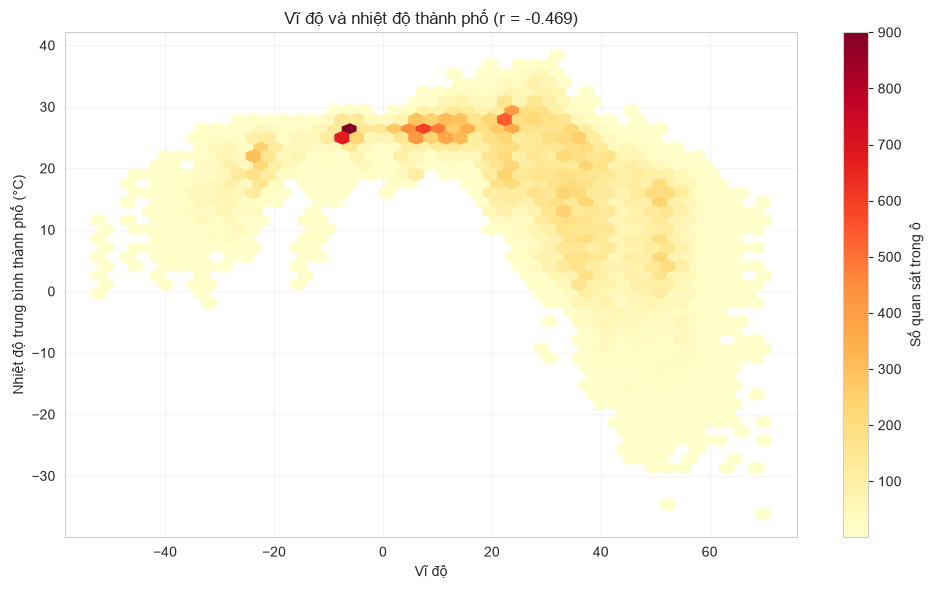

In [20]:
# So sánh vĩ độ với nhiệt độ thành phố trên mẫu trực quan hóa.
latitude_plot = multivariate_sample[['latitude', target_col]].dropna()
latitude_correlation = latitude_plot['latitude'].corr(latitude_plot[target_col])

fig, ax = plt.subplots(figsize=(10, 6))
hexbin = ax.hexbin(
    latitude_plot['latitude'],
    latitude_plot[target_col],
    gridsize=45,
    cmap='YlOrRd',
    mincnt=1,
)
fig.colorbar(hexbin, ax=ax, label='Số quan sát trong ô')
ax.set_title(f'Vĩ độ và nhiệt độ thành phố (r = {latitude_correlation:.3f})')
ax.set_xlabel('Vĩ độ')
ax.set_ylabel('Nhiệt độ trung bình thành phố (°C)')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(REPORT_IMAGES / '06_latitude_vs_city_temperature.png', dpi=300, bbox_inches='tight')
plt.show()


##### Nhận xét kết quả

Các ô có mật độ quan sát cao cho thấy nhiệt độ thành phố nhìn chung giảm khi vĩ độ có dấu tăng về phía Bắc. Kết quả tương quan ở Mục 3.4 cho toàn bộ dữ liệu là khoảng **r = −0,467**, tức là có quan hệ âm mức vừa phải: các thành phố ở vĩ độ Bắc cao có xu hướng lạnh hơn. Tuy nhiên, các điểm vẫn phân tán rộng vì nhiệt độ còn chịu ảnh hưởng của mùa, vị trí ven biển/nội lục và đặc điểm riêng của từng thành phố.

Vĩ độ có dấu chỉ phản ánh một phần quan hệ khí hậu. Ở Notebook 05 nên cân nhắc thêm `abs(latitude)` để biểu diễn khoảng cách tới xích đạo, vì cả hai bán cầu đều có xu hướng lạnh hơn khi đi xa xích đạo.


#### 3.5.2 Nhiệt độ trung bình quốc gia và nhiệt độ thành phố

Biểu đồ kiểm tra mức độ đồng biến giữa nhiệt độ trung bình cấp quốc gia và nhiệt độ của từng thành phố trong cùng dữ liệu. Mối quan hệ mạnh là hợp lý về mặt khí hậu, nhưng khi dự báo nhiệt độ thực tế cần xác định thời điểm có sẵn của biến quốc gia để tránh sử dụng thông tin cùng kỳ không thể biết trước.


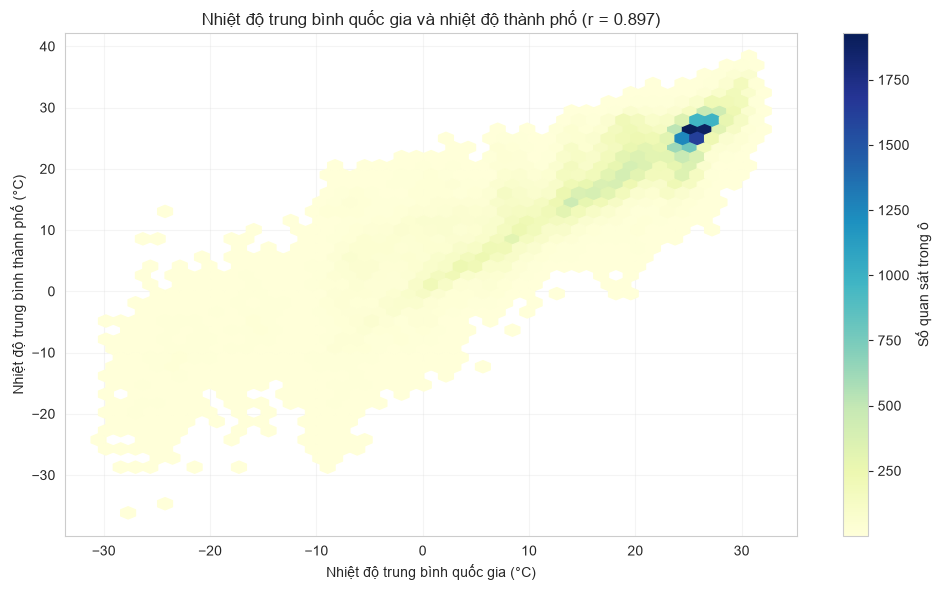

In [21]:
# So sánh nhiệt độ trung bình quốc gia với nhiệt độ thành phố.
country_plot = multivariate_sample[
    ['country_average_temperature', target_col]
].dropna()
country_correlation = country_plot['country_average_temperature'].corr(
    country_plot[target_col]
)

fig, ax = plt.subplots(figsize=(10, 6))
hexbin = ax.hexbin(
    country_plot['country_average_temperature'],
    country_plot[target_col],
    gridsize=45,
    cmap='YlGnBu',
    mincnt=1,
)
fig.colorbar(hexbin, ax=ax, label='Số quan sát trong ô')
ax.set_title(
    'Nhiệt độ trung bình quốc gia và nhiệt độ thành phố '
    f'(r = {country_correlation:.3f})'
)
ax.set_xlabel('Nhiệt độ trung bình quốc gia (°C)')
ax.set_ylabel('Nhiệt độ trung bình thành phố (°C)')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(REPORT_IMAGES / '07_country_vs_city_temperature.png', dpi=300, bbox_inches='tight')
plt.show()


##### Nhận xét kết quả

Biểu đồ tạo thành xu hướng đồng biến rõ rệt: thành phố thuộc quốc gia có nhiệt độ trung bình cao thường cũng có nhiệt độ cao hơn. Trên toàn bộ dữ liệu, Mục 3.4 ghi nhận hệ số tương quan khoảng **r = 0,897**, phù hợp với ý nghĩa của biến nhiệt độ trung bình quốc gia.

Tuy vậy, tương quan cao không đồng nghĩa biến này luôn được phép dùng trực tiếp khi dự báo. Nếu `country_average_temperature` được tính từ cùng thời điểm với giá trị cần dự báo, nó có thể đưa thông tin đương thời vào mô hình. Notebook 05 cần xác định rõ thời điểm sẵn có của biến hoặc tạo biến trễ (lag) phù hợp trước khi huấn luyện.


#### 3.5.3 Heatmap tương quan của các biến cốt lõi

Heatmap tóm tắt tương quan tuyến tính giữa biến mục tiêu, vị trí, thời gian và một số chỉ số nhiệt độ tổng hợp. Chỉ các biến phục vụ diễn giải EDA được giữ lại để biểu đồ không bị rối. Các hệ số cao giữa các biến nhiệt độ tổng hợp là dấu hiệu cần kiểm tra trùng lặp thông tin ở Notebook 05, không phải bằng chứng đủ để giữ hay loại ngay một biến.


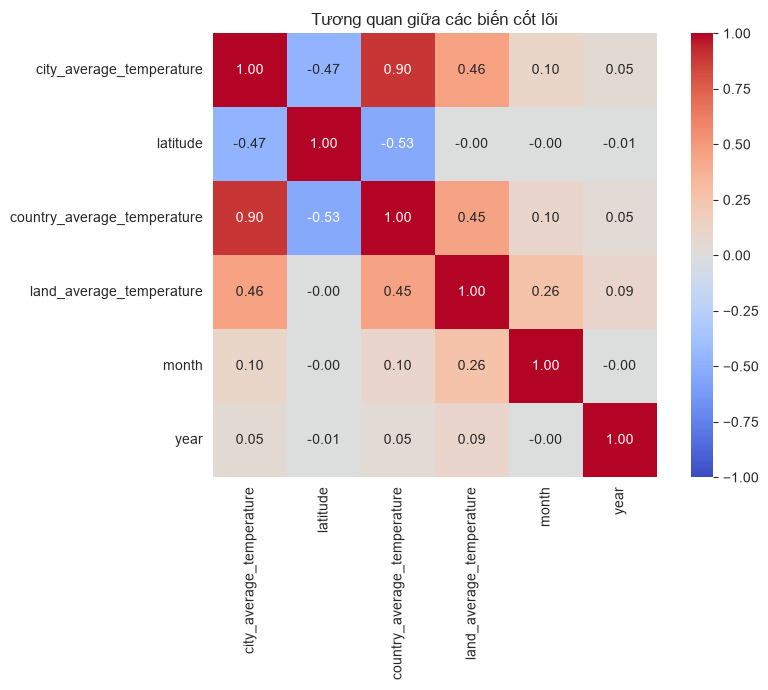

In [22]:
# Tính ma trận tương quan cho nhóm biến cốt lõi trên cùng mẫu dữ liệu.
CORE_CORRELATION_COLUMNS = [
    target_col,
    'latitude',
    'country_average_temperature',
    'land_average_temperature',
    'month',
    'year',
]

core_correlation = multivariate_sample[CORE_CORRELATION_COLUMNS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    core_correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax,
)
ax.set_title('Tương quan giữa các biến cốt lõi')
plt.tight_layout()
plt.savefig(REPORT_IMAGES / '08_core_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


##### Nhận xét kết quả

Heatmap giúp nhìn đồng thời chiều và mức độ quan hệ giữa các biến. Trong đó, `country_average_temperature` có tương quan dương mạnh với biến mục tiêu, còn `latitude` có tương quan âm mức vừa phải. `month` và `year` chỉ có tương quan tuyến tính yếu với nhiệt độ thành phố; điều này không phủ nhận tác động của mùa vụ và xu hướng dài hạn, mà cho thấy các quan hệ này không thuần tuyến tính.

Các ô tương quan cao giữa những chỉ số nhiệt độ tổng hợp là tín hiệu cần kiểm tra đa cộng tuyến trước khi xây dựng mô hình. Heatmap là công cụ sàng lọc ở EDA; quyết định giữ, loại hoặc biến đổi biến sẽ được thực hiện có kiểm soát ở Notebook 05, đồng thời tránh sử dụng các biến có nguy cơ rò rỉ dữ liệu.


### 3.6 Time Series Analysis (Phân tích theo thời gian)

Phần này mô tả nhiệt độ theo thời gian ở ba góc độ: xu hướng dài hạn theo năm, tính mùa vụ theo tháng và số lượng bản ghi theo năm. Các phép tổng hợp được thực hiện trên toàn bộ `df`, không lấy mẫu, để kết quả đại diện cho dữ liệu sạch đã đọc từ PostgreSQL.


#### 3.6.1 Xu hướng nhiệt độ trung bình theo năm

Biểu đồ đường thể hiện nhiệt độ thành phố trung bình của từng năm. Đường này phù hợp để nhận diện thay đổi dài hạn, nhưng cần được đọc cùng biểu đồ độ bao phủ ở Mục 3.6.3 vì số lượng thành phố quan sát được không cố định qua các năm.


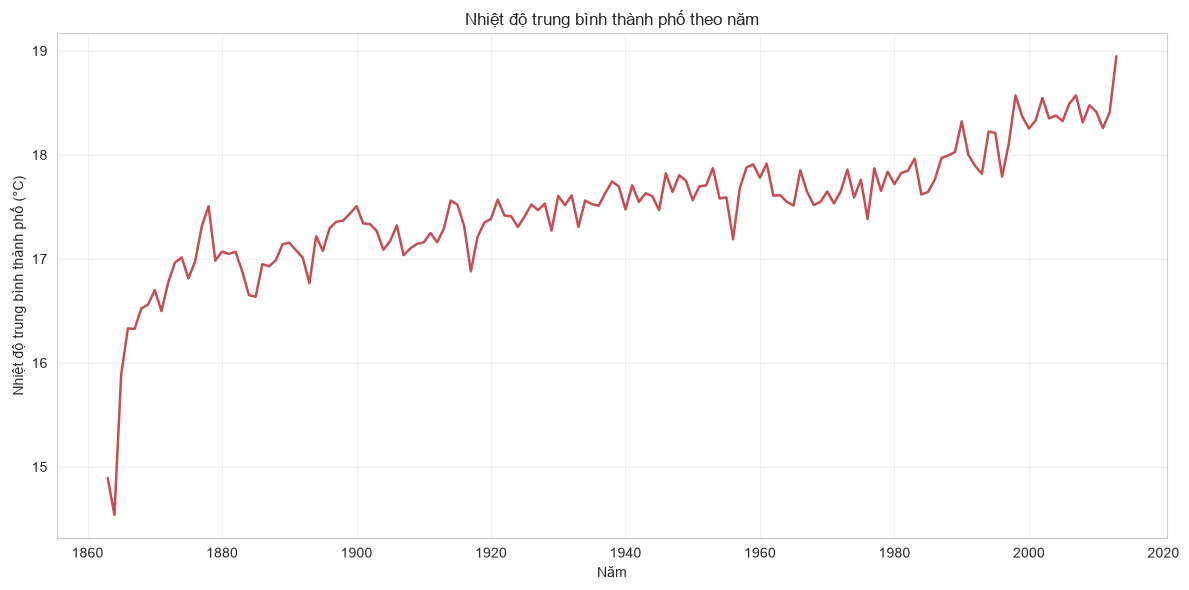

Thay đổi trung bình theo hai đầu chuỗi: 0.0270°C/năm


In [23]:
# Tổng hợp nhiệt độ và số quan sát hợp lệ theo năm.
yearly_temperature = (
    df.groupby('year', as_index=False)
    .agg(
        mean_city_temperature=(target_col, 'mean'),
        record_count=(target_col, 'count'),
    )
)

first_year = yearly_temperature.iloc[0]
last_year = yearly_temperature.iloc[-1]
yearly_change = (
    (last_year['mean_city_temperature'] - first_year['mean_city_temperature'])
    / (last_year['year'] - first_year['year'])
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    yearly_temperature['year'],
    yearly_temperature['mean_city_temperature'],
    color='#C44E52',
    linewidth=1.8,
)
ax.set_title('Nhiệt độ trung bình thành phố theo năm')
ax.set_xlabel('Năm')
ax.set_ylabel('Nhiệt độ trung bình thành phố (°C)')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(REPORT_IMAGES / '09_yearly_temperature_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Thay đổi trung bình theo hai đầu chuỗi: {yearly_change:.4f}°C/năm')


#### Nhận xét kết quả 3.6.1

Đường nhiệt độ trung bình theo năm có xu hướng tăng dài hạn. So sánh hai đầu chuỗi cho mức thay đổi xấp xỉ **+0,027°C mỗi năm** trong giai đoạn đang quan sát. Tuy nhiên, năm 2013 chỉ có dữ liệu đến tháng 9, nên không nên xem điểm cuối năm 2013 như một trung bình năm hoàn chỉnh hoặc dùng riêng nó để kết luận về tốc độ ấm lên.

Xu hướng cần được đọc cùng Mục 3.6.3: độ bao phủ quan sát thay đổi theo thời gian có thể ảnh hưởng đến trung bình năm. Trong Notebook 05, `year` hoặc số năm từ mốc ban đầu có thể được cân nhắc như đặc trưng xu hướng dài hạn, tách biệt với đặc trưng mùa vụ.


#### 3.6.2 Mùa vụ theo tháng

Biểu đồ này tổng hợp nhiệt độ trung bình của tất cả thành phố theo tháng trong năm. Mục tiêu là quan sát chu kỳ mùa vụ; do tháng là biến tuần hoàn, hình dạng của đường quan trọng hơn hệ số tương quan tuyến tính đơn giản giữa số tháng và nhiệt độ.


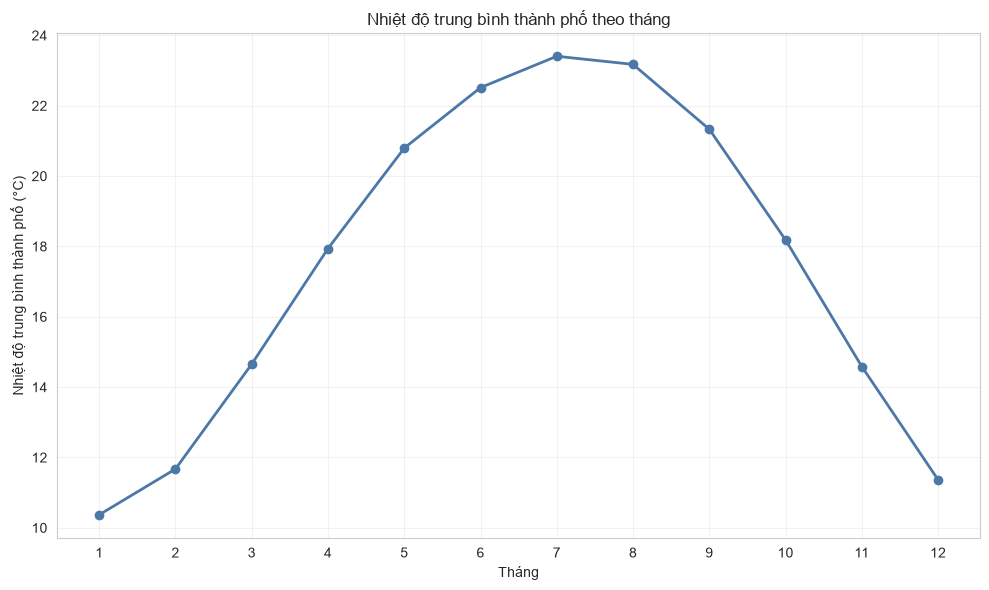

Nóng nhất: tháng 7 (23.41°C)
Lạnh nhất: tháng 1 (10.37°C)


In [24]:
# Tổng hợp nhiệt độ trung bình theo tháng trên toàn bộ giai đoạn.
monthly_temperature = (
    df.groupby('month', as_index=False)
    .agg(
        mean_city_temperature=(target_col, 'mean'),
        record_count=(target_col, 'count'),
    )
    .sort_values('month')
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    monthly_temperature['month'],
    monthly_temperature['mean_city_temperature'],
    marker='o',
    color='#4C78A8',
    linewidth=2,
)
ax.set_title('Nhiệt độ trung bình thành phố theo tháng')
ax.set_xlabel('Tháng')
ax.set_ylabel('Nhiệt độ trung bình thành phố (°C)')
ax.set_xticks(range(1, 13))
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(REPORT_IMAGES / '10_monthly_seasonality.png', dpi=300, bbox_inches='tight')
plt.show()

hottest_month = monthly_temperature.loc[
    monthly_temperature['mean_city_temperature'].idxmax()
]
coldest_month = monthly_temperature.loc[
    monthly_temperature['mean_city_temperature'].idxmin()
]
print(
    f'Nóng nhất: tháng {int(hottest_month["month"])} '
    f'({hottest_month["mean_city_temperature"]:.2f}°C)'
)
print(
    f'Lạnh nhất: tháng {int(coldest_month["month"])} '
    f'({coldest_month["mean_city_temperature"]:.2f}°C)'
)


##### Nhận xét kết quả

Đường biểu diễn thể hiện chu kỳ mùa vụ rõ rệt: tháng **7** là tháng nóng nhất với nhiệt độ trung bình khoảng **23,41°C**, còn tháng **1** lạnh nhất với khoảng **10,37°C**. Chênh lệch khoảng **13,04°C** cho thấy mùa vụ là tín hiệu quan trọng đối với nhiệt độ thành phố.

Quan hệ này có dạng tuần hoàn, không phải tuyến tính: tháng 12 và tháng 1 gần nhau về khí hậu nhưng lại cách xa nhau nếu xem tháng là số nguyên. Vì vậy, Notebook 05 nên mã hóa tháng bằng đặc trưng tuần hoàn sin/cos hoặc nhóm mùa thay vì chỉ dùng trực tiếp số tháng.


#### 3.6.3 Độ bao phủ dữ liệu theo năm

Biểu đồ số bản ghi theo năm được thêm vào để kiểm tra liệu biến động ở biểu đồ xu hướng nhiệt độ có thể chịu ảnh hưởng từ thay đổi độ bao phủ dữ liệu hay không. Đây là kiểm tra chất lượng diễn giải, không phải một biến dùng trực tiếp để dự báo.


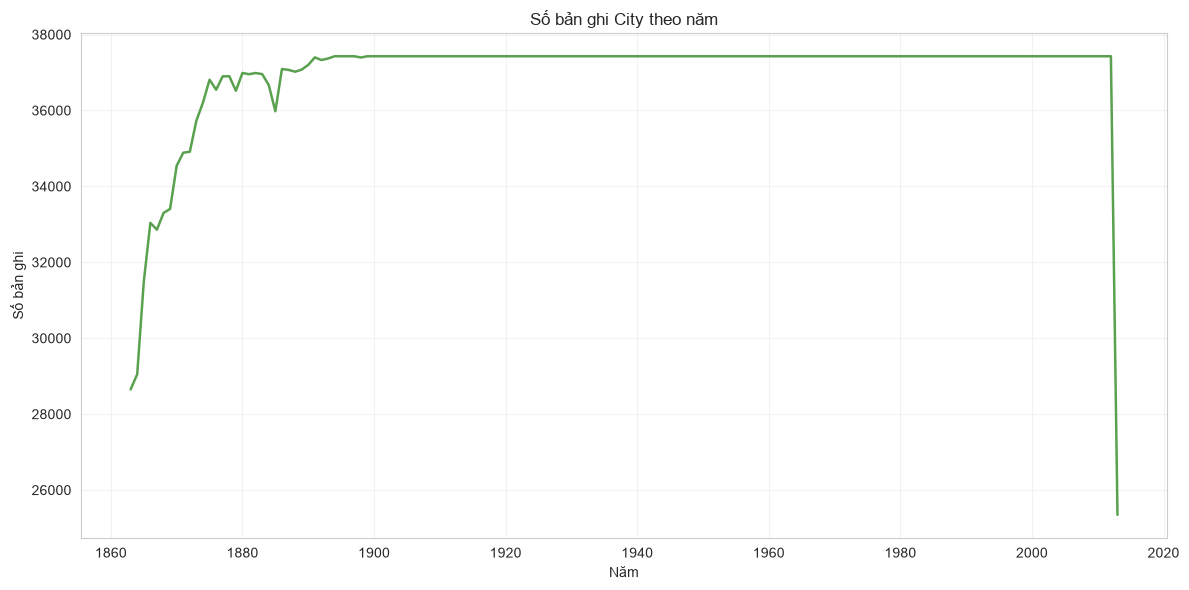

,year,record_count
0,1863,28650
1,1864,29049
2,1865,31486
3,1866,33038
4,1867,32859


,year,record_count
146,2009,37428
147,2010,37428
148,2011,37428
149,2012,37428
150,2013,25346


In [25]:
# Dùng số quan sát đã tổng hợp ở Mục 3.6.1 để trực quan hóa độ bao phủ theo năm.
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    yearly_temperature['year'],
    yearly_temperature['record_count'],
    color='#59A14F',
    linewidth=1.8,
)
ax.set_title('Số bản ghi City theo năm')
ax.set_xlabel('Năm')
ax.set_ylabel('Số bản ghi')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(REPORT_IMAGES / '11_yearly_record_coverage.png', dpi=300, bbox_inches='tight')
plt.show()

display(yearly_temperature[['year', 'record_count']].head())
display(yearly_temperature[['year', 'record_count']].tail())


#### Nhận xét kết quả 3.6.3

Số bản ghi tăng từ **28.650** ở năm 1863 lên khoảng **37.428** ở các năm hoàn chỉnh 2009–2012. Năm 2013 chỉ có **25.346** dòng vì dữ liệu kết thúc ở tháng 9, không phải vì số thành phố giảm đột ngột. Vì vậy, biểu đồ cần được diễn giải theo cả số tháng quan sát của từng năm.

Trung bình nhiệt độ của các năm đầu và cuối không được tính từ cùng độ bao phủ thành phố/thời gian. Khi diễn giải xu hướng dài hạn hoặc đánh giá mô hình theo thời gian, cần lưu ý **coverage bias**; có thể đánh giá bổ sung trên một tập thành phố ổn định và chỉ dùng các năm đủ 12 tháng nếu cần so sánh công bằng giữa các giai đoạn.


## 4. Kết luận EDA

### 4.1. Các phát hiện chính

**Dữ liệu và biến mục tiêu**

- Bộ dữ liệu sạch có **5.579.085 dòng** và **32 cột**. Biến mục tiêu duy nhất là `city_average_temperature`, không có giá trị thiếu.
- Nhiệt độ trung bình là **17,50°C**, median **19,83°C**, độ lệch chuẩn **10,19°C**; giá trị nhỏ nhất và lớn nhất lần lượt là **−42,70°C** và **39,16°C**. Phân bố lệch trái do các quan sát rất lạnh ở thành phố/vùng mùa đông.

**Độ bao phủ không gian và mối quan hệ biến**

- Pipeline giữ lại **50 quốc gia**, gồm **3.070 tên thành phố**; `country_name` và `city_name` không thiếu dữ liệu. India và China là hai quốc gia có nhiều bản ghi nhất, nên kết quả tổng hợp có thể chịu ảnh hưởng lớn hơn từ hai quốc gia này.
- `latitude` có tương quan âm mức vừa phải với nhiệt độ thành phố (khoảng **r = −0,467**). `country_average_temperature` có tương quan dương mạnh (khoảng **r = 0,897**), nhưng cần kiểm soát thời điểm có sẵn của biến này nếu dùng để dự báo.
- `major_city_average_temperature` trùng khớp hoàn toàn với target trên tập con có giá trị, nên không phù hợp làm đặc trưng đầu vào trực tiếp vì có nguy cơ rò rỉ dữ liệu.

**Thời gian và mùa vụ**

- Tháng **7** nóng nhất (**23,41°C**) và tháng **1** lạnh nhất (**10,37°C**), chênh lệch **13,04°C**. Đây là bằng chứng rõ về tính mùa vụ tuần hoàn.
- Trung bình năm có xu hướng tăng dài hạn; so sánh hai đầu chuỗi cho kết quả xấp xỉ **+0,027°C/năm**. Tuy nhiên, năm 2013 chỉ có dữ liệu đến tháng 9, nên kết quả này chỉ nên được xem là mô tả ban đầu và cần đọc cùng độ bao phủ dữ liệu.
- Số dòng tăng từ **28.650** ở năm 1863 lên khoảng **37.428** ở các năm hoàn chỉnh 2009–2012; năm 2013 có **25.346** dòng do thiếu ba tháng cuối. Các năm không có cùng độ bao phủ thành phố, vì vậy cần lưu ý **coverage bias** khi so sánh dài hạn.


### 4.2. Ý nghĩa cho bài toán dự báo

- Dùng `city_average_temperature` làm biến mục tiêu duy nhất. Các cột nhiệt độ tổng hợp cùng kỳ không nên được đưa vào mô hình một cách mặc định, vì có thể tạo rò rỉ thông tin tùy theo thời điểm dự báo.
- Mùa vụ nên được biểu diễn bằng `sin(month)` và `cos(month)` hoặc biến `season`; dùng riêng số tháng 1–12 không thể hiện đúng việc tháng 12 và tháng 1 liền kề về khí hậu.
- `latitude` và đặc biệt `abs(latitude)` là các đặc trưng địa lý có cơ sở từ EDA. Khóa địa điểm nên dùng tổ hợp `country_name`, `city_name`, `latitude` và `longitude`, không chỉ dùng tên thành phố.
- Chia dữ liệu huấn luyện/kiểm tra theo thời gian là cần thiết để đánh giá dự báo thực tế và hạn chế rò rỉ từ tương lai. Năm 2013 không đủ 12 tháng nên cần được xử lý có chủ đích khi tạo tập đánh giá.
- Các biến nhiệt độ có tương quan cao cần được rà soát đa cộng tuyến. Việc giữ hay loại biến phải dựa trên thời điểm sẵn có, ý nghĩa nghiệp vụ và cách tính đặc trưng, không chỉ dựa vào hệ số tương quan.


### 4.3. Kích hoạt cho Notebook 05: Feature Engineering

1. Tạo đặc trưng thời gian tuần hoàn: `month_sin`, `month_cos` và/hoặc `season`.
2. Tạo đặc trưng địa lý `abs(latitude)`; đồng thời chuẩn hóa khóa vị trí bằng `country_name`, `city_name`, `latitude`, `longitude`.
3. Tạo biến xu hướng như `years_since_start`; xác định rõ cách xử lý năm 2013 không đủ tháng trước khi chia dữ liệu theo thời gian.
4. Lập danh sách kiểm soát rò rỉ: loại `major_city_average_temperature` khỏi feature đầu vào; chỉ dùng `country_average_temperature` hoặc các biến nhiệt độ tổng hợp nếu được tạo từ dữ liệu lịch sử có sẵn tại thời điểm dự báo.
5. Rà soát các biến nhiệt độ tương quan cao và chọn tập đặc trưng gọn, có ý nghĩa. Sau đó thực hiện chia train/validation/test theo thời gian trước mọi bước encoding hoặc scaling học từ dữ liệu.


## 5. Liên Kết Sang Notebook 05: Feature Engineering

### 5.1. Tóm tắt chuyển tiếp

Notebook 04 đã hoàn thành EDA trên bảng `cleaned_city_temperature` từ PostgreSQL. Các kết quả quan trọng để chuyển sang Notebook 05 gồm:

- Biến mục tiêu duy nhất là `city_average_temperature`.
- Dữ liệu có mùa vụ rõ rệt, xu hướng dài hạn và khác biệt khí hậu theo vị trí địa lý.
- `latitude`, đặc biệt là `abs(latitude)`, có ý nghĩa địa lý; tháng cần được biểu diễn theo chu kỳ.
- Một số biến nhiệt độ tổng hợp cần kiểm tra về thời điểm sẵn có và rủi ro leakage trước khi đưa vào mô hình.
- Độ bao phủ theo thời gian không hoàn toàn đồng đều; năm 2013 chỉ có dữ liệu đến tháng 9.


### 5.2. Chuẩn bị cho Notebook 05: Feature Engineering

Notebook 05 sẽ xây dựng tập đặc trưng theo các nguyên tắc sau:

1. Tạo đặc trưng mùa vụ tuần hoàn, ví dụ `month_sin`, `month_cos` hoặc `season`.
2. Tạo đặc trưng địa lý như `abs(latitude)` và sử dụng tổ hợp quốc gia–thành phố–tọa độ khi cần định danh vị trí.
3. Tạo đặc trưng xu hướng thời gian, ví dụ `years_since_start`, sau khi quyết định cách xử lý năm 2013 chưa đủ tháng.
4. Rà soát các biến nhiệt độ có tương quan cao, kiểm tra thời điểm dữ liệu sẵn có và loại các biến có rủi ro leakage, đặc biệt `major_city_average_temperature`.
5. Nếu sử dụng lag hoặc rolling statistics, chúng phải được tạo sau khi sắp xếp theo thời gian và chỉ dùng quan sát quá khứ của đúng địa điểm; không tạo từ dữ liệu tương lai.
6. Thực hiện chia train/validation/test theo thời gian trước các bước encoding, scaling hoặc tính thống kê học từ dữ liệu.


### 5.3. Quy trình tiếp theo

```text
03_data_cleaning
        ↓
04_eda_visualization  (hoàn thành)
        ↓
05_feature_engineering
        ↓
06_machine_learning
        ↓
07_prediction_demo
```

Notebook 05 sẽ tiếp nhận bảng sạch và các kết luận EDA ở trên; Notebook 06 chỉ sử dụng tập đặc trưng đã được kiểm soát leakage và chia theo thời gian.


## 6. Ghi chú và hướng dẫn chạy Notebook

### 6.1. Điều kiện trước khi chạy

1. Hoàn thành Notebook 03 và xác nhận bảng `public.cleaned_city_temperature` đã tồn tại trong PostgreSQL.
2. Đảm bảo dịch vụ PostgreSQL đang chạy và máy có thể kết nối đến database đã cấu hình.
3. Tạo file `.env` tại thư mục gốc dự án. File này không được đẩy lên Git và cần có các biến sau:

```text
DB_HOST=localhost
DB_PORT=5432
DB_NAME=climate_db
DB_USER=postgres
DB_PASSWORD=<mật_khẩu_PostgreSQL>
```

4. Cài các thư viện cần thiết trong đúng môi trường Python đang chạy notebook:

```bash
pip install pandas numpy matplotlib seaborn psycopg2-binary python-dotenv
```

### 6.2. Cách chạy

1. Mở `04_eda_visualization.ipynb` trong Jupyter hoặc VS Code.
2. Chạy các cell từ trên xuống để thiết lập thư viện, đường dẫn, kết nối PostgreSQL và đọc dữ liệu.
3. Kiểm tra output ở Mục 2.3: notebook phải in được kích thước dữ liệu sau khi đọc bảng sạch.
4. Chạy tiếp các mục EDA theo thứ tự. Các biểu đồ được lưu vào `reports/images/`.

### 6.3. Xử lý lỗi thường gặp

| Lỗi hoặc dấu hiệu | Nguyên nhân thường gặp | Cách xử lý |
|---|---|---|
| `ModuleNotFoundError` với `psycopg2`, `dotenv`, `seaborn`... | Thiếu thư viện trong kernel hiện tại | Cài lại thư viện bằng lệnh ở Mục 6.1, sau đó chọn đúng Python interpreter/kernel. |
| `ValueError: Thiếu cấu hình trong .env` | File `.env` thiếu một hoặc nhiều biến `DB_*` | Kiểm tra tên biến và giá trị trong `.env`; không chèn khoảng trắng thừa quanh dấu `=`. |
| `OperationalError` hoặc `Connection refused` | PostgreSQL chưa chạy, sai host/port/database/user/password | Khởi động PostgreSQL, kiểm tra lại `.env`, sau đó thử kết nối bằng pgAdmin4 hoặc `psql`. |
| `relation "public.cleaned_city_temperature" does not exist` | Notebook 03 chưa tạo/lưu bảng sạch vào database hiện tại | Chạy phần lưu dữ liệu của Notebook 03, hoặc kiểm tra lại `DB_NAME` trong `.env`. |
| Không lưu được ảnh biểu đồ | Thư mục `reports/images/` chưa tồn tại hoặc không có quyền ghi | Tạo thư mục `reports/images/` trong project và kiểm tra quyền ghi. |
| Kernel thiếu bộ nhớ hoặc chạy chậm | Bảng có hơn 5 triệu dòng | Chạy từng mục theo thứ tự; Mục 3.5 đã dùng mẫu 50.000 dòng cho biểu đồ đa biến. |

### 6.4. Tùy chỉnh an toàn

- Biến mục tiêu của notebook được cố định là `city_average_temperature` để thống nhất với các notebook trước; không thay đổi tùy ý nếu chưa cập nhật các phần EDA liên quan.
- Có thể đổi tên hoặc độ phân giải ảnh tại các lệnh `plt.savefig(...)` trong từng cell biểu đồ.
- Nếu thay đổi cấu hình kết nối, chỉ cập nhật `.env`; không ghi mật khẩu trực tiếp vào notebook.
- Khi dùng dữ liệu hoặc database khác, cần chạy lại toàn bộ notebook để các bảng tổng hợp và biểu đồ cùng phản ánh một nguồn dữ liệu.